Ensemble Method:
Ensemble ka matlab hota hai multiple models ko mila kar ek strong model banana.

3 sabse famous methods hain.
Ensemble Learning

      |
------------------------
|          |          |
Bagging   Boosting  Stacking

Bagging:(Bootstrap Aggregating)
Ek hi data se
multiple datasets banao
Sabse famous algorithm:
Random Forest for Bagging
Original Data
1000 records
ab hum Bootstrap kary gay mean asa kuch karna ni hota lakin ya hoti hain backend main

Bootstrap Sampling:
Tree 1 ---> 1000 random records
Tree 2 ---> 1000 random records
Tree 3 ---> 1000 random records

Har tree different data dekhega.
man lo first tree main 1000 row tu hogi lakin 4 ya koi b random row ni aye gi ya koi b random row do bar a jaye gi or har tree main koi b randon coumn aye gay lain select waho hoga jis ki gini ya enthropy zeyada hogi

jasy tree one ne bola cat two bola dog asa random ans aye ab Majority Voting hogi jo sb se zeyad hoga wahi final ans hoga lakin ya classification hoga Majority Voting agar random forest regression howa tu Average liya jata hai


Agar har tree:
Same rows use kare
Same columns use kare
To 100 trees lagbhag ek jaise ban jayenge.
Aur agar sab ek jaise hain to 100 trees banane ka koi fayda nahi.

Bootstrap Sampling: Har tree ko random rows di jati hain.
Random Feature Selection: Har split par random subset of features select ki jati hai, aur un mein se best feature (Gini ya Entropy ki bunyaad par) split ke liye choose ki jati hai.


Bagging
Ek hi type ke models (aksar Decision Trees)
Har model alag bootstrap data par train hota hai
Final result majority vote/average

In [1]:
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [3]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
pred = model.predict(X_test)
pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [7]:
print(accuracy_score(y_test,pred))

1.0


In [9]:
for i, tree in enumerate(model.estimators_):

    pred = tree.predict(X_test)

    print(
        "Tree",
        i+1,
        "predict values",
        tree.predict(X_test),
        "accuracy_score",
        accuracy_score(y_test, pred)
    )

Tree 1 predict values [1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 2. 0. 2.
 2. 2. 2. 2. 0. 0.] accuracy_score 1.0
Tree 2 predict values [1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 1. 0. 2.
 2. 2. 2. 2. 0. 0.] accuracy_score 0.9666666666666667
Tree 3 predict values [1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 2. 0. 2.
 2. 2. 2. 2. 0. 0.] accuracy_score 1.0
Tree 4 predict values [2. 0. 2. 1. 2. 0. 1. 1. 2. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 1. 0. 2.
 2. 2. 2. 2. 0. 0.] accuracy_score 0.8333333333333334
Tree 5 predict values [1. 0. 2. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 1. 0. 2.
 2. 2. 2. 2. 0. 0.] accuracy_score 0.9
Tree 6 predict values [1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 2. 0. 2.
 2. 2. 2. 2. 0. 0.] accuracy_score 1.0
Tree 7 predict values [1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 2. 0. 2.
 2. 2. 2. 2. 0. 0.] accuracy_score 1.0
Tree 8 predict values [1. 0. 2. 

Boosting:
Bagging aur Boosting mein sabse bada difference.

Tree1
↓
Mistakes
↓
Tree2
↓
Mistakes
↓
Tree3

Previous tree ki mistakes seekhta hai.

Example
Teacher Pehli baar 5 questions galat.
Teacher again Sirf un 5 questions par dubara practice karata hai.
Phir 2 galat.
Phir 1 galat.
Yehi Boosting hai.

Popular Algorithms
AdaBoost
Gradient Boosting
XGBoost
LightGBM
CatBoost

Boosting
Ek hi type ke weak models sequentially
Har model pichle model ki mistakes improve karta hai
Final result weighted combination

In [10]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = AdaBoostClassifier(n_estimators=50,random_state=42)
model.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [12]:
pred = model.predict(X_test)
pred

array([1, 0, 2, 1, 1, 0, 1, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [13]:
print(accuracy_score(y_test,pred))

0.9333333333333333


In [14]:
for i, tree in enumerate(model.estimators_):

    pred = tree.predict(X_test)

    print(
        "Tree",
        i+1,
        "predict values",
        tree.predict(X_test),
        "accuracy_score",
        accuracy_score(y_test, pred)
    )

Tree 1 predict values [1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0] accuracy_score 0.6333333333333333
Tree 2 predict values [0 0 2 0 2 0 0 2 0 0 2 0 0 0 0 0 2 0 0 2 0 2 0 2 2 2 2 2 0 0] accuracy_score 0.7
Tree 3 predict values [1 1 2 1 1 1 1 2 1 1 2 1 1 1 1 1 2 1 1 2 1 2 1 2 2 2 2 2 1 1] accuracy_score 0.6666666666666666
Tree 4 predict values [1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0] accuracy_score 0.6333333333333333
Tree 5 predict values [2 0 2 2 2 0 2 2 2 2 2 0 0 0 0 2 2 2 2 2 0 2 0 2 2 2 2 2 0 0] accuracy_score 0.7
Tree 6 predict values [1 1 2 1 1 1 1 2 1 1 2 1 1 1 1 1 2 1 1 2 1 1 1 2 2 2 2 2 1 1] accuracy_score 0.6333333333333333
Tree 7 predict values [2 0 2 2 2 0 2 2 2 2 2 0 0 0 0 2 2 2 2 2 0 2 0 2 2 2 2 2 0 0] accuracy_score 0.7
Tree 8 predict values [1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0] accuracy_score 0.6333333333333333
Tree 9 predict values [2 1 2 2 2 1 1 2 2 1 2 1 1 1 1 2 2 1 2 2 1 2 1 2 2 2 2 2 1 1] accuracy_score 0.

Shape of X : (150, 4)
Shape of y : (150,)

Training Samples : 120
Testing Samples : 30

Model Training Completed.

Total Trees : 3

Trees Inside Random Forest

Tree 1
DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)
----------------------------------------
Tree 2
DecisionTreeClassifier(max_features='sqrt', random_state=1273642419)
----------------------------------------
Tree 3
DecisionTreeClassifier(max_features='sqrt', random_state=1935803228)
----------------------------------------


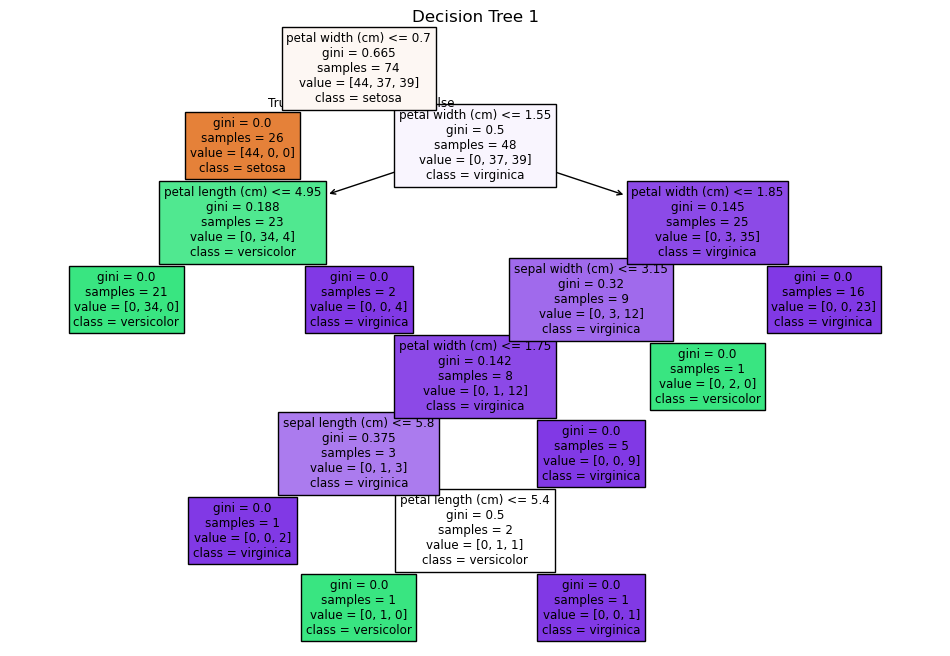

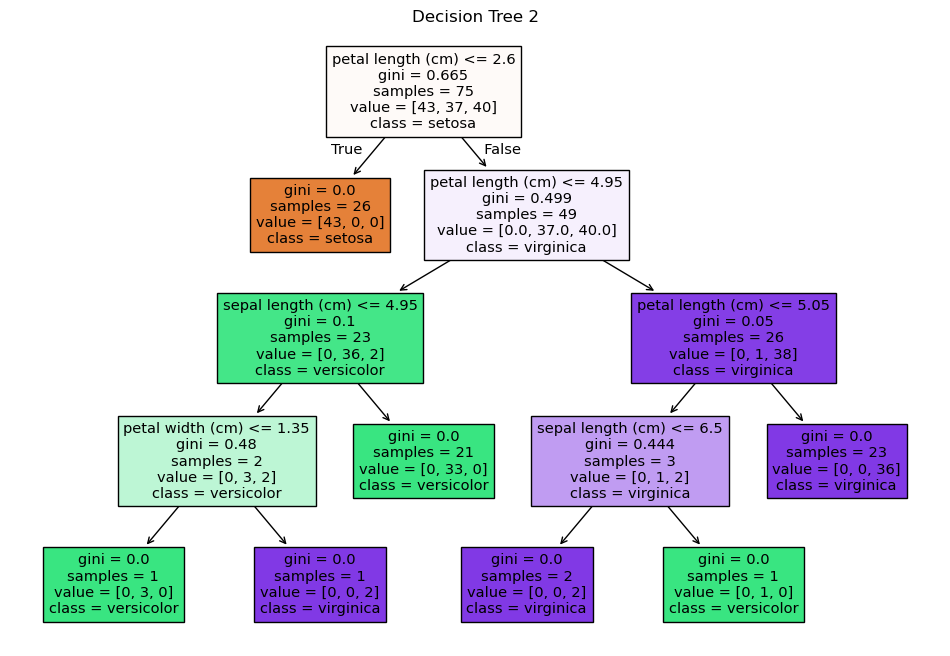

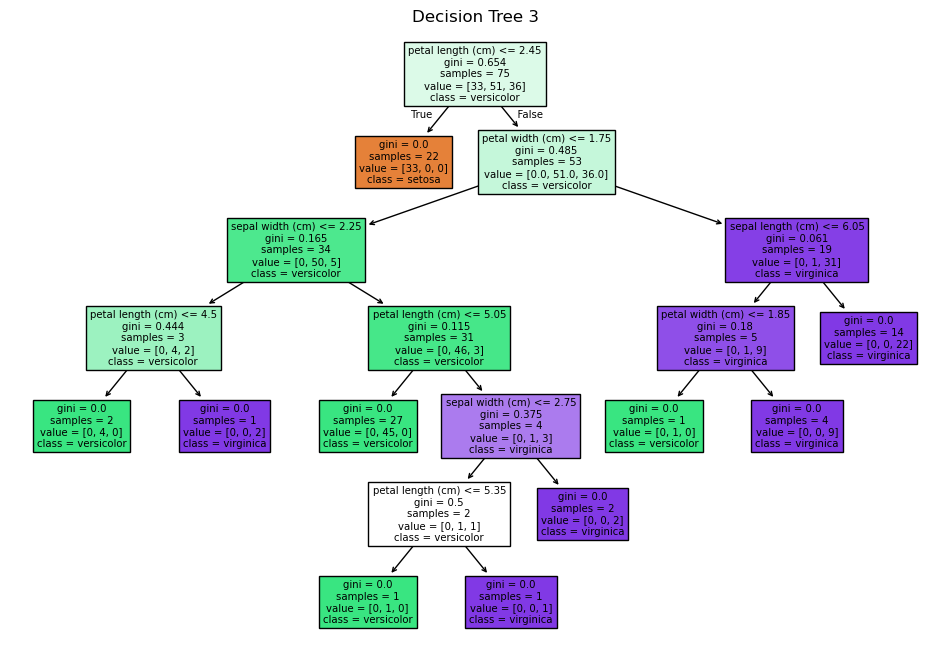


Prediction of Every Tree

Tree 1
[1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 2. 0. 2.
 2. 2. 2. 2. 0. 0.]
----------------------------------------
Tree 2
[1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 1. 0. 2.
 2. 2. 2. 2. 0. 0.]
----------------------------------------
Tree 3
[1. 0. 2. 1. 1. 0. 1. 2. 1. 1. 2. 0. 0. 0. 0. 1. 2. 1. 1. 2. 0. 2. 0. 2.
 2. 2. 2. 2. 0. 0.]
----------------------------------------

Accuracy of Every Tree

Tree 1 Accuracy : 1.00
Tree 2 Accuracy : 0.97
Tree 3 Accuracy : 1.00

Final Prediction

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Random Forest Accuracy : 1.0

Feature Importance

sepal length (cm) : 0.014039568390614383
sepal width (cm) : 0.017829067568337412
petal length (cm) : 0.5331675983664204
petal width (cm) : 0.43496376567462774

First Tree Object

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)

Second Tree Object

DecisionTreeClassifier(max_features='sqrt', random_stat

In [15]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))


model = RandomForestClassifier(
    # Number of Decision Trees
    n_estimators=3,
    # Same random result every run
    random_state=42,
    # Random Rows (Bootstrap Sampling)
    bootstrap=True
)

model.fit(X_train, y_train)

print("\nModel Training Completed.")

#estimators_ ek list hoti hai jisme Random Forest ke andar bane hue tamam Decision Trees store #hote hain. Is list ke zariye hum har tree ko alag access karke uski prediction, accuracy aur #visualization dekh sakte hain.
print("\nTotal Trees :", len(model.estimators_))


print("\nTrees Inside Random Forest\n")
for i, tree in enumerate(model.estimators_):
    print("Tree", i + 1)
    print(tree)
    print("-" * 40)

for i, tree in enumerate(model.estimators_):
    plt.figure(figsize=(12,8))
    plot_tree(
        tree,
        filled=True,
        feature_names=iris.feature_names,
        class_names=iris.target_names
    )
    plt.title(f"Decision Tree {i+1}")
    plt.show()

print("\nPrediction of Every Tree\n")
for i, tree in enumerate(model.estimators_):
    pred = tree.predict(X_test)
    print("Tree", i+1)
    print(pred)
    print("-"*40)


print("\nAccuracy of Every Tree\n")
for i, tree in enumerate(model.estimators_):
    pred = tree.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"Tree {i+1} Accuracy : {acc:.2f}")


final_prediction = model.predict(X_test)
print("\nFinal Prediction\n")
print(final_prediction)

final_accuracy = accuracy_score(y_test,final_prediction)
print("\nRandom Forest Accuracy :", final_accuracy)



print("\nFeature Importance\n")
for feature, importance in zip(iris.feature_names,model.feature_importances_):
    print(feature, ":", importance)

first_tree = model.estimators_[0]
print("\nFirst Tree Object\n")
print(first_tree)

second_tree = model.estimators_[1]
print("\nSecond Tree Object\n")
print(second_tree)

third_tree = model.estimators_[2]
print("\nThird Tree Object\n")
print(third_tree)

Stacking:
                 Dataset
                    │
     ┌──────────────┼──────────────┐
     │              │              │
Decision Tree      SVM      Logistic Regression
     │              │              │
 Prediction      Prediction     Prediction
     └──────────────┼──────────────┘
                    │
          Meta Model (Final Model)
                    │
             Final Prediction


Model 1 = Decision Tree
Model 2 = SVM
Model 3 = Logistic Regression
In teeno ki predictions ko ek naya model leta hai.
Us naye model ko Meta Learner kehte hain.

Stacking
Mukhtalif algorithms (Decision Tree, SVM, Logistic Regression, etc.)
Sab models ki predictions ek Meta Model ko di jati hain
Final result Meta Learner deta hai

In [16]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Model 1
model1 = LogisticRegression(max_iter=200)
# Model 2
model2 = DecisionTreeClassifier(random_state=42)
# Model 3
model3 = RandomForestClassifier(n_estimators=50,random_state=42)

base_models = [('logistic', model1),('decision_tree', model2),('random_forest', model3)]

meta_model = LogisticRegression()
stack_model = StackingClassifier(estimators=base_models,final_estimator=meta_model)

stack_model.fit(X_train, y_train)
print("Training Complete")

print("\nIndividual Model Predictions & Accuracy")
for name, model in base_models:
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    print("\nModel :", name)
    print(pred)
    acc = accuracy_score(y_test,pred)
    print(name,"Accuracy:",acc)


final_prediction = stack_model.predict(X_test)
print("\nStacking Final Prediction")
print(final_prediction)

final_accuracy = accuracy_score(y_test, final_prediction)
print("\nStacking Accuracy:",final_accuracy)

Training Complete

Individual Model Predictions & Accuracy

Model : logistic
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
logistic Accuracy: 1.0

Model : decision_tree
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
decision_tree Accuracy: 1.0

Model : random_forest
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
random_forest Accuracy: 1.0

Stacking Final Prediction
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Stacking Accuracy: 1.0


Meta model ka kaam "best model select karna" nahi hota.
Uska kaam hota hai:
"Multiple models ki predictions ko combine karke ek better final prediction banana."
meta model ko jo model deya jate hain wo on ko asa input feature treate krta hain 

In [ ]:
# Actual vs Prediction bhi dekh sakte ho
result = pd.DataFrame({
    "Actual": y_test,
    "Prediction": final_prediction})

# print(result)

In [26]:
import numpy as np

coef = stack_model.final_estimator_.coef_
# Absolute values lo

importance = np.abs(coef) #abs ne absolute keya - hata deya
# Har base model ke 3 columns ka sum
print(importance)
model_importance = {

    "Logistic Regression":
    importance[:,0:3].sum(),

    "Decision Tree":
    importance[:,3:6].sum(),

    "Random Forest":
    importance[:,6:9].sum()

}


print(model_importance)

[[1.03858604e+00 5.08144224e-01 5.37134329e-01 1.09477481e+00
  5.75830015e-01 5.25637315e-01 1.09119415e+00 5.62521180e-01
  5.35365489e-01]
 [4.79806672e-01 1.32273088e+00 8.39574149e-01 5.69213323e-01
  5.72301978e-01 2.61402125e-04 5.62707980e-01 6.90072175e-01
  1.24014138e-01]
 [5.58779363e-01 8.14586655e-01 1.37670848e+00 5.25561489e-01
  3.52803701e-03 5.25375913e-01 5.28486171e-01 1.27550996e-01
  6.59379628e-01]]
{'Logistic Regression': np.float64(7.476050784856305), 'Decision Tree': np.float64(4.392484284031234), 'Random Forest': np.float64(4.881291906999267)}
